## 🍄 Mushroom Classification Project

🟢 Step 0: Problem বুঝে নেওয়া
🎯 Goal কী?

মাশরুম খাওয়ার যোগ্য (edible) নাকি বিষাক্ত (poisonous) — এটা প্রেডিক্ট করা।

Target Column:
class


e = edible

p = poisonous

👉 এটা একটা Binary Classification Problem

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


In [2]:
# Step 2

df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
df.shape


(8124, 23)

মানে:

8124 rows

23 columns

In [4]:
df.columns


Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')

🟢 Step 4: Missing Value আছে কিনা দেখা

In [5]:
df.isnull().sum()

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

🟢 Step 5: Target Variable বুঝা

In [6]:
df['class'].value_counts()

class
e    4208
p    3916
Name: count, dtype: int64

🟢 Step 6: Data Visualization শুরু

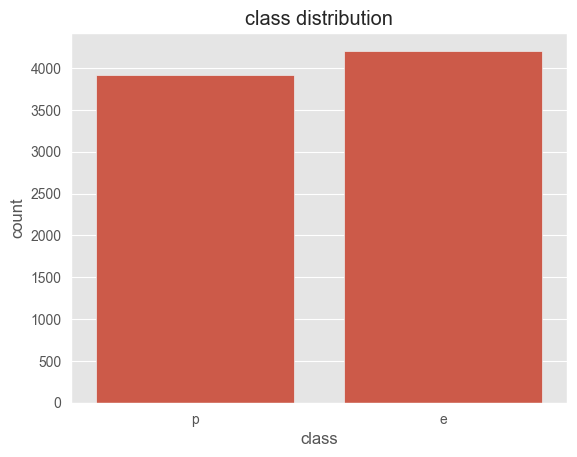

In [7]:
sns.countplot(x='class', data=df)
plt.title("class distribution")
plt.show()

Step 7: একটি Feature বিশ্লেষণ (Example: odor)

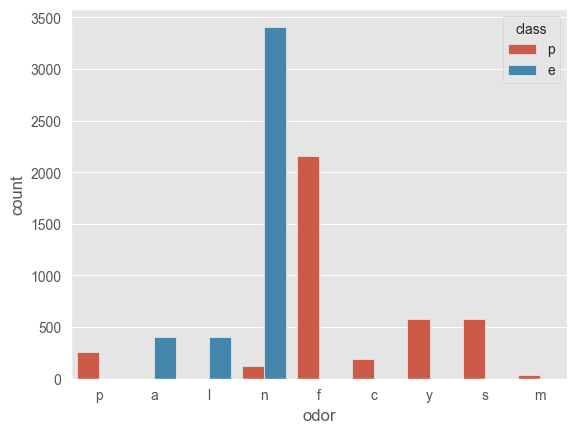

In [8]:
sns.countplot(x='odor', hue='class', data=df)
plt.xticks(rotation=0)
plt.show()

Step 8: Encoding (Machine Learning এর জন্য)

In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

### 🔍 ব্যাখ্যা:

| Code | কী করছে |
|------|---------|
| `from sklearn.preprocessing import LabelEncoder` | sklearn থেকে `LabelEncoder` class টা import করছে |
| `le = LabelEncoder()` | LabelEncoder এর একটা **object** (instance) বানাচ্ছে |
| `df.copy()` | original `df` কে না বদলে একটা **নতুন copy** বানাচ্ছে |
| `for col in df_encoded.columns:` | প্রতিটা column এর উপর দিয়ে **loop** চলছে |
| `le.fit_transform(...)` | দুটো কাজ একসাথে করছে: ১) `fit` = unique values গুলো মনে রাখা ২) `transform` = সেগুলো number এ বদলানো |

**উদাহরণ:**
```
'e', 'p'  →  0, 1
'n', 'y'  →  0, 1


## Step 9: Feature & Target আলাদা করা


In [10]:
X = df_encoded.drop('class', axis=1)
Y = df_encoded['class']


## 🟢 Step 10: Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train ,Y_test = train_test_split(
    X,Y, test_size = 0.2, random_state = 42
)


## 🟢 Step 11: Model বানানো (Decision Tree)


In [12]:

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None



## 🟢 Step 12: Prediction করা

In [13]:
Y_pred = model.predict(X_test)


## 🟢 Step 13: Accuracy দেখা

In [14]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test, Y_pred)
print(accuracy)

1.0


In [15]:
print(len(Y_test))   # 1625 হওয়া উচিত
print(len(Y_pred))   # এটাও 1625 হতে হবে

1625
1625



# Assignment — ৩টা Task

🟢 Task 1: Missing Values

In [16]:
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())


class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64

Total missing: 0



## Step 1.2 — Hidden Missing Values ধরা

এই dataset এ isnull() তে সব 0 দেখাবে — কিন্তু আসলে stalk-root column এ ? দিয়ে missing mark করা আছে!

In [18]:
for col in df.columns:
    if '?' in df[col].values:
        count = (df[col] == '?').sum()
        print(f"{col}: {count}")

stalk-root: 2480



## Step 1.3 — Imputation Method ঠিক করা

💡 Imputation মানে missing value এর জায়গায় কিছু বসানো।

In [ ]:
df['stalk-root'] = df['stalk-root'].replace('?', np.nan)

mode_value = df['stalk-root'].mode()[0]
df['stack-root'] = df['stalk-root'].fillna(mode_value)




## 🟢 Task 2: Categorical Encoding

In [19]:
print("Categorical Encoding")
print(df.select_dtypes(include='object').columns.tolist())
print("\nমোট categorical columns:",df.select_dtypes(include='object').shape[1])

Categorical Encoding
['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

মোট categorical columns: 23



## Step 2.2 — Encoding পদ্ধতি ঠিক করা

In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df_encoded = df.copy()

for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Before encoding")
print(df[['class', 'cap-shape','odor']].head(3))

print("After encoding")
print(df_encoded[['class', 'cap-shape','odor']].head(3))



Before encoding
  class cap-shape odor
0     p         x    p
1     e         x    a
2     e         b    l
After encoding
   class  cap-shape  odor
0      1          5     6
1      0          5     0
2      0          0     3



## 🟢 Task 3: Feature Scaling

In [22]:
print("প্রতিটা column এর value range:")
print(df_encoded.describe().loc[['min','max']])

প্রতিটা column এর value range:
     class  cap-shape  cap-surface  cap-color  bruises  odor  gill-attachment  \
min    0.0        0.0          0.0        0.0      0.0   0.0              0.0   
max    1.0        5.0          3.0        9.0      1.0   8.0              1.0   

     gill-spacing  gill-size  gill-color  ...  stalk-surface-below-ring  \
min           0.0        0.0         0.0  ...                       0.0   
max           1.0        1.0        11.0  ...                       3.0   

     stalk-color-above-ring  stalk-color-below-ring  veil-type  veil-color  \
min                     0.0                     0.0        0.0         0.0   
max                     8.0                     8.0        0.0         3.0   

     ring-number  ring-type  spore-print-color  population  habitat  
min          0.0        0.0                0.0         0.0      0.0  
max          2.0        4.0                8.0         5.0      6.0  

[2 rows x 23 columns]



## Step 3.2 — Scaling দরকার কিনা সিদ্ধান্ত নেওয়া

In [23]:
print("সিদ্ধান্ত:")
print("এই dataset এ Decision Tree ব্যবহার করছি।")
print("Decision Tree distance-based না — তাই scaling দরকার নেই।")
print("কিন্তু practice এর জন্য আমরা apply করবো।")

সিদ্ধান্ত:
এই dataset এ Decision Tree ব্যবহার করছি।
Decision Tree distance-based না — তাই scaling দরকার নেই।
কিন্তু practice এর জন্য আমরা apply করবো।



## Step 3.3 — Scaling Apply করা (Practice)

In [26]:
from sklearn.preprocessing import MinMaxScaler

X = df_encoded.drop('class', axis=1)
Y = df_encoded['class']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

import pandas as pd
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("before SCALLING")
print(X[['cap-shape','odor','stalk-root']].head(3))

print("after SCALLING")
print(X_scaled[['cap-shape','odor', 'stalk-root']].head(3))


before SCALLING
   cap-shape  odor  stalk-root
0          5     6           3
1          5     0           2
2          0     3           2
after SCALLING
   cap-shape   odor  stalk-root
0        1.0  0.750        0.75
1        1.0  0.000        0.50
2        0.0  0.375        0.50
